In [1]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

creds, _ = default()
gc = gspread.authorize(creds)

SOURCE_SHEET_NAME = 'Rezultate simulare 1'

print(f"Fetching data from '{SOURCE_SHEET_NAME}'...")
source_workbook = gc.open(SOURCE_SHEET_NAME)
source_sheet = source_workbook.sheet1 # Grabs the first tab

Fetching data from 'Rezultate simulare 1'...


In [2]:
# Convert the Google Sheet into a pandas DataFrame
data = source_sheet.get_all_values()
df = pd.DataFrame(data[1:], columns=data[0])

print("Data loaded successfully! Processing...")

# Parse JSON
df['parsed_json'] = df['JSON Brut'].apply(json.loads)
unpacked_df = pd.json_normalize(df['parsed_json'])
df = pd.concat([df.drop(columns=['JSON Brut', 'parsed_json']), unpacked_df], axis=1)

# Time calculations
df['timp_folosit_minutes'] = pd.to_timedelta(df['timp_folosit'])
df['timp_folosit_minutes'] = df['timp_folosit_minutes'].dt.total_seconds() / 60
df['timp_folosit_minutes'] = df['timp_folosit_minutes'].round(0)

column_to_move = df.pop('timp_folosit_minutes')
df.insert(2, 'timp_folosit_minutes', column_to_move)

# New column names
info_names = [f"problema_{i}_info" for i in range(1, 11)]
mate_names = [f"problema_{i}_mate" for i in range(1, 11)]
problem_names = [f"Problema {i}" for i in range(1, 11)]

# Populate math answers
mate_df = df.explode('detalii_mate')
expanded_mate = mate_df['detalii_mate'].apply(pd.Series)
correct_mate = expanded_mate['correct']
correct_mate = correct_mate.rename('mate-answer-key')

reshaped_mate = expanded_mate['answer'].values.reshape(-1, 10)
mate_ans = pd.DataFrame(reshaped_mate, columns=mate_names)

# Populate info answers
info_df = df.explode('detalii_info')
expanded_info = info_df['detalii_info'].apply(pd.Series)
correct_info = expanded_info['correct']
correct_info = correct_info.rename('info-answer-key')

reshaped_info = expanded_info['answer'].values.reshape(-1, 10)
info_ans = pd.DataFrame(reshaped_info, columns=info_names)

# Add results together
cleaned_df = df.drop(columns=['detalii_info', 'detalii_mate'])

cleaned_df = cleaned_df.reset_index(drop=True)
correct_info = correct_info.reset_index(drop=True)
correct_mate = correct_mate.reset_index(drop=True)
mate_ans = mate_ans.reset_index(drop=True)
info_ans = info_ans.reset_index(drop=True)

mate_answer_key = pd.Series(correct_mate.iloc[:10].values)
info_answer_key = pd.Series(correct_info.iloc[:10].values)

final_barem = pd.DataFrame({
    'Numar Problema': problem_names,
    'Mate': mate_answer_key,
    'Info': info_answer_key
})

final_df = pd.concat([cleaned_df, mate_ans, info_ans], axis=1)

minutes_spent = 20
longer_sessions_only = final_df[final_df['timp_folosit_minutes'] >= minutes_spent]
longer_sessions_only.fillna
longer_sessions_only

Data loaded successfully! Processing...


,Data,Cod,timp_folosit_minutes,Scor Total,Info,Mate,Timp,id_participant,timp_folosit,scor_total,...,problema_1_info,problema_2_info,problema_3_info,problema_4_info,problema_5_info,problema_6_info,problema_7_info,problema_8_info,problema_9_info,problema_10_info
1,21.03.2026 15:32:31,ST203750,22.0,6,0,6,22min 22s,ST203750,22min 22s,6,...,a,a,e,a,a,e,a,a,a,a
2,21.03.2026 15:36:45,ST607073,25.0,10,3,7,24min 46s,ST607073,24min 46s,10,...,d,b,e,b,d,e,e,b,b,d
4,21.03.2026 15:56:50,ST538470,47.0,7,0,7,46min 34s,ST538470,46min 34s,7,...,None,None,None,None,None,None,None,None,None,None
6,21.03.2026 16:10:28,ST35618,44.0,15,10,5,43min 33s,ST35618,43min 33s,15,...,d,d,b,c,b,d,c,b,e,d
7,21.03.2026 16:32:43,ST258185,79.0,12,4,8,1h 19min 24s,ST258185,1h 19min 24s,12,...,b,b,c,c,b,c,a,a,e,d
8,21.03.2026 16:47:04,ST426423,97.0,18,8,10,1h 36min 46s,ST426423,1h 36min 46s,18,...,d,d,b,c,b,d,e,a,e,d
9,21.03.2026 16:52:30,ST529373,102.0,7,0,7,1h 42min 21s,ST529373,1h 42min 21s,7,...,None,None,None,None,None,None,None,None,None,None
10,21.03.2026 16:55:52,ST702813,64.0,7,1,6,1h 3min 53s,ST702813,1h 3min 53s,7,...,b,d,e,b,a,b,d,a,a,c
11,21.03.2026 16:57:32,ST696159,86.0,14,7,7,1h 25min 52s,ST696159,1h 25min 52s,14,...,d,d,f,c,b,d,d,f,e,d
12,21.03.2026 17:11:42,ST965933,122.0,15,7,8,2h 1min 31s,ST965933,2h 1min 31s,15,...,d,d,b,c,b,b,b,b,b,d


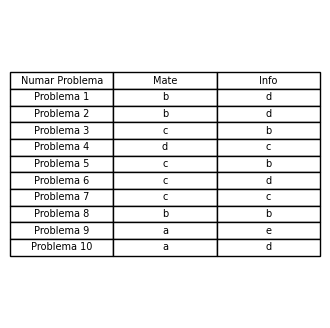

In [3]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.axis('tight')
ax.axis('off')
ax.table(cellText=final_barem.values, colLabels=final_barem.columns, loc='center', cellLoc='center')
plt.show()

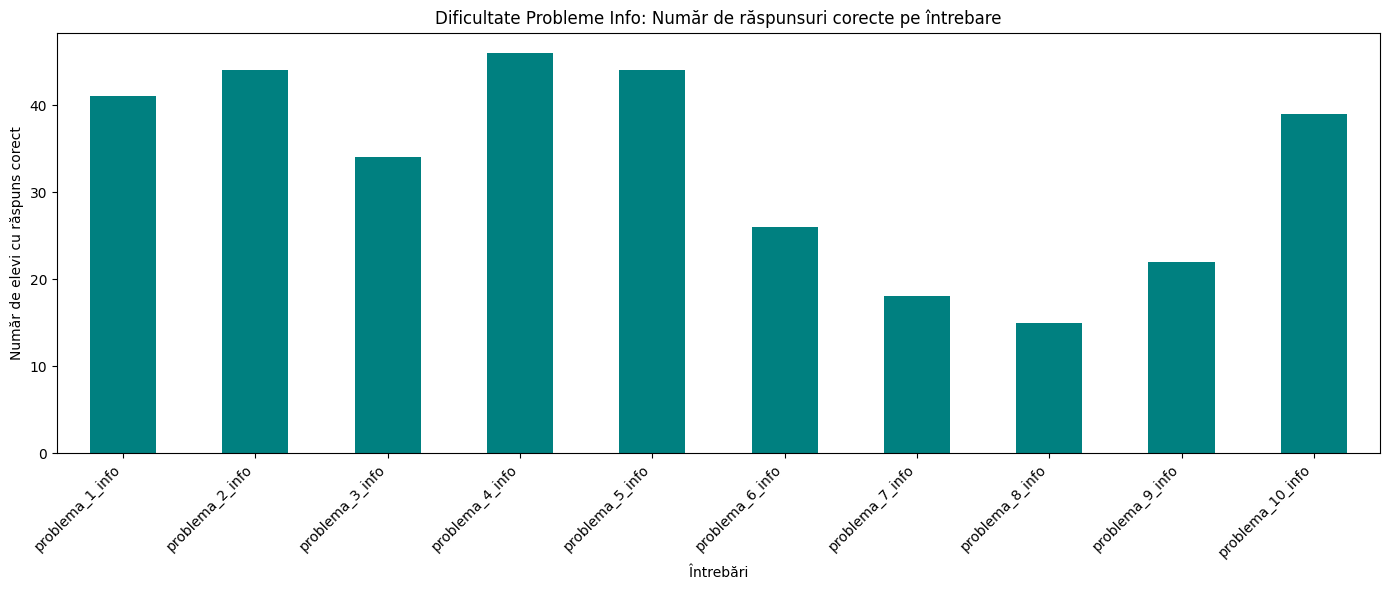

In [4]:
# Info Plot
info_answers = final_df.iloc[:, 22:32]
info_correct = info_answers == info_answer_key.values
info_problem_scores = info_correct.sum(axis=0)

plt.figure(figsize=(14, 6))
info_problem_scores.plot(kind='bar', color='teal')
plt.title('Dificultate Probleme Info: Număr de răspunsuri corecte pe întrebare')
plt.ylabel('Număr de elevi cu răspuns corect')
plt.xlabel('Întrebări')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

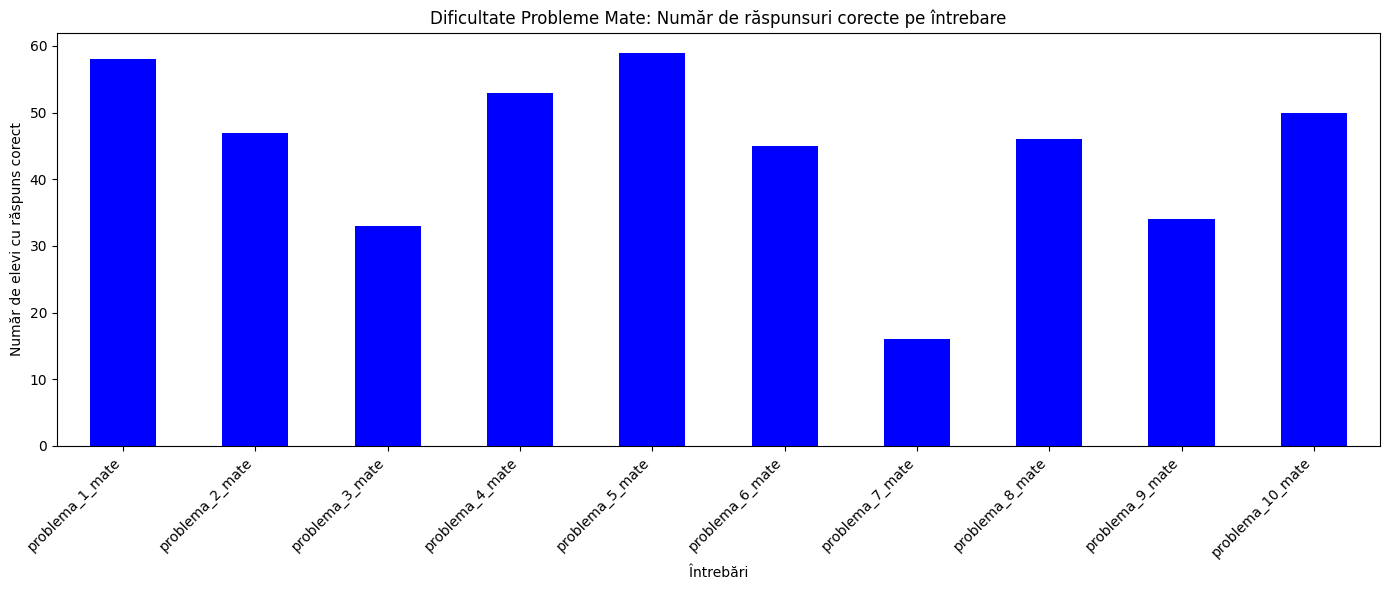

In [5]:
# Math Plot
math_answers = final_df.iloc[:, 12:22]
math_correct = math_answers == mate_answer_key.values
math_problem_scores = math_correct.sum(axis=0)

plt.figure(figsize=(14, 6))
math_problem_scores.plot(kind='bar', color='blue')
plt.title('Dificultate Probleme Mate: Număr de răspunsuri corecte pe întrebare')
plt.ylabel('Număr de elevi cu răspuns corect')
plt.xlabel('Întrebări')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

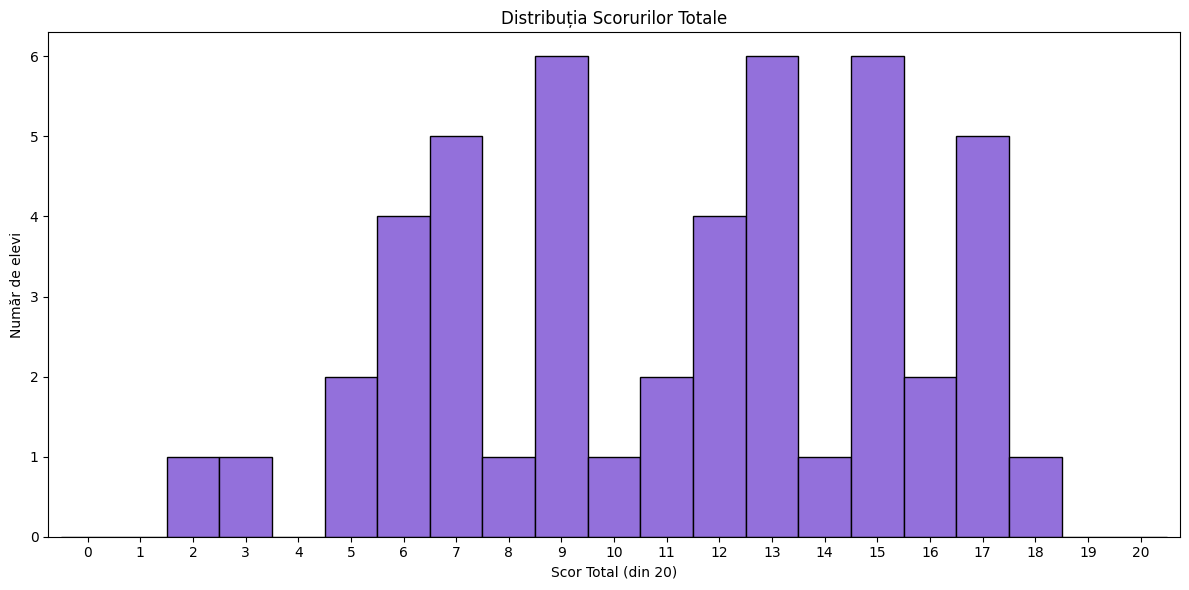

In [6]:
# Total score Distribution Plot
score_counts = longer_sessions_only['scor_total'].astype(int).value_counts()
all_possible_scores = range(0, 21)
score_distribution = score_counts.reindex(all_possible_scores, fill_value=0)

plt.figure(figsize=(12, 6))
score_distribution.plot(kind='bar', color='mediumpurple', edgecolor='black', width=1.0)
plt.title('Distribuția Scorurilor Totale')
plt.xlabel('Scor Total (din 20)')
plt.ylabel('Număr de elevi')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

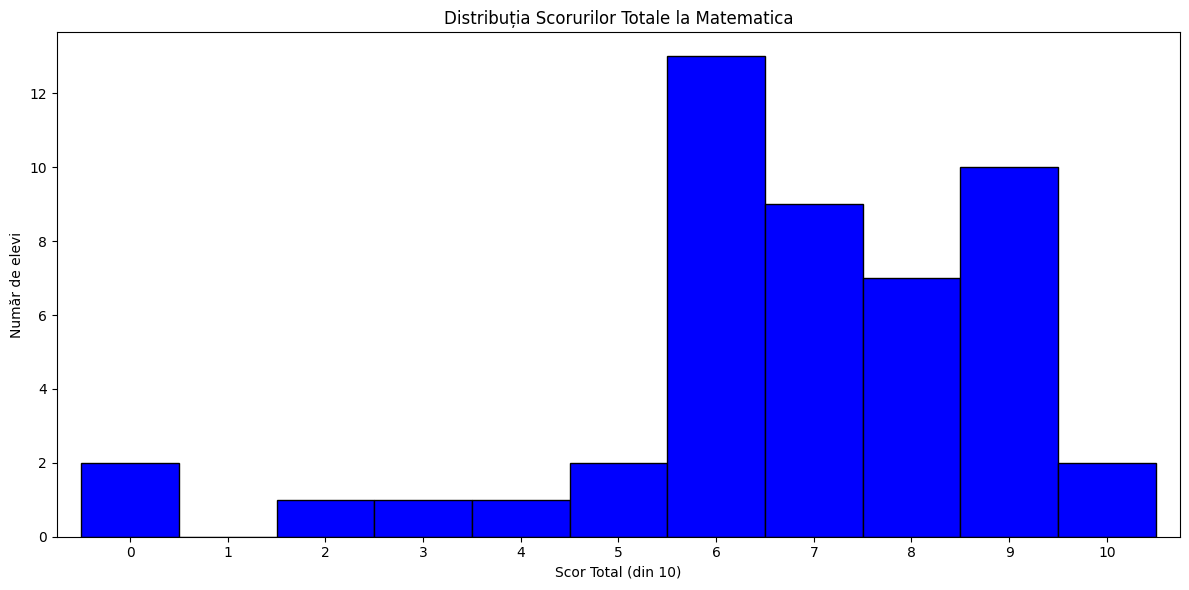

In [7]:
# Math score Distribution Plot
columns_to_check = longer_sessions_only.columns[12:22]
longer_sessions_clean = longer_sessions_only.dropna(subset=columns_to_check, thresh=5)

score_counts = longer_sessions_only['Mate'].astype(int).value_counts()
all_possible_scores = range(0, 11)
score_distribution = score_counts.reindex(all_possible_scores, fill_value=0)

plt.figure(figsize=(12, 6))
score_distribution.plot(kind='bar', color='blue', edgecolor='black', width=1.0)
plt.title('Distribuția Scorurilor Totale la Matematica')
plt.xlabel('Scor Total (din 10)')
plt.ylabel('Număr de elevi')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

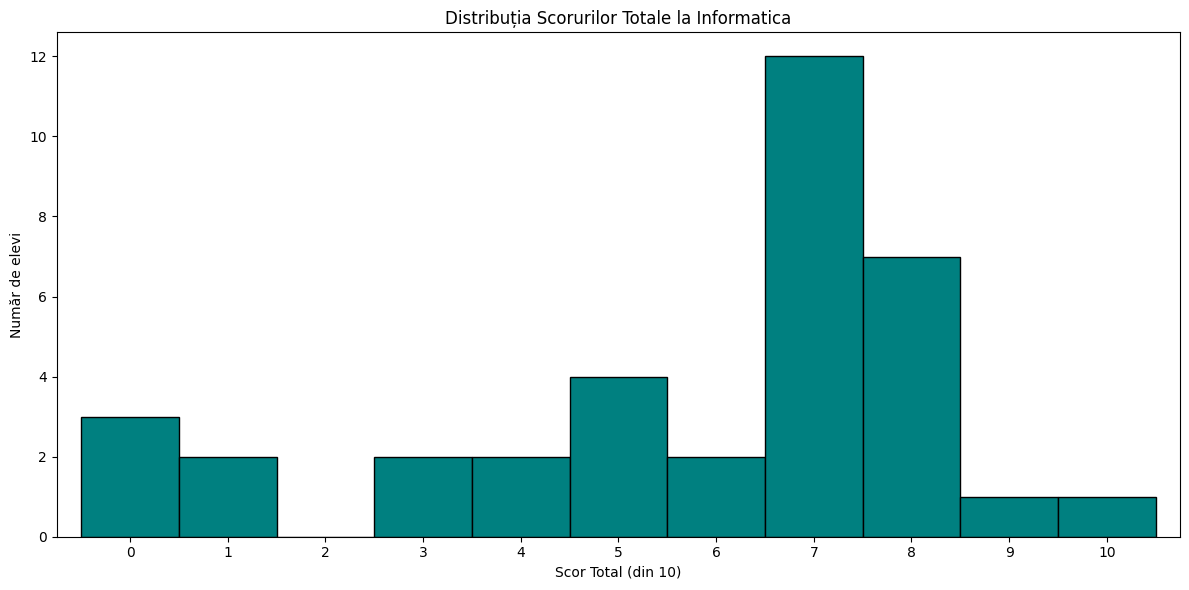

In [8]:
# Info score Distribution Plot
columns_to_check = longer_sessions_only.columns[22:32]
longer_sessions_clean = longer_sessions_only.dropna(subset=columns_to_check, thresh=5)

score_counts = longer_sessions_clean['Info'].astype(int).value_counts()
all_possible_scores = range(0, 11)
score_distribution = score_counts.reindex(all_possible_scores, fill_value=0)

plt.figure(figsize=(12, 6))
score_distribution.plot(kind='bar', color='teal', edgecolor='black', width=1.0)
plt.title('Distribuția Scorurilor Totale la Informatica')
plt.xlabel('Scor Total (din 10)')
plt.ylabel('Număr de elevi')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Prepare the final dataframe
sorted_df = longer_sessions_only.sort_values(by='scor_total', ascending=False)

to_be_exported = sorted_df.drop(columns=[
    'timp_folosit_minutes',
    'timp_folosit',
    'scor_total',
    'scor_info',
    'scor_mate',
    'id_participant'
])

export_safe_df = to_be_exported.fillna('').astype(str)

DESTINATION_SHEET_NAME = 'Simulare 1 - admiterepoli '

print(f"Creating new sheet '{DESTINATION_SHEET_NAME}' and uploading data...")

try:
    # Try to open the sheet if it already exists to overwrite it
    new_workbook = gc.open(DESTINATION_SHEET_NAME)
    new_sheet = new_workbook.sheet1
    new_sheet.clear() # Clears old data before writing new
except gspread.SpreadsheetNotFound:
    # If it doesn't exist, create it
    new_workbook = gc.create(DESTINATION_SHEET_NAME)
    new_sheet = new_workbook.sheet1

output_data = [export_safe_df.columns.values.tolist()] + export_safe_df.values.tolist()

# Write to the Google Sheet
new_sheet.update(values=output_data, range_name='A1')

print("✅ Workflow Complete")

Creating new sheet 'Simulare 1 - admiterepoli ' and uploading data...
✅ Workflow Complete
